In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model as lm

In [31]:
df = pd.read_csv("homeprices.csv")
df

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


Text(0, 0.5, 'prices USD')

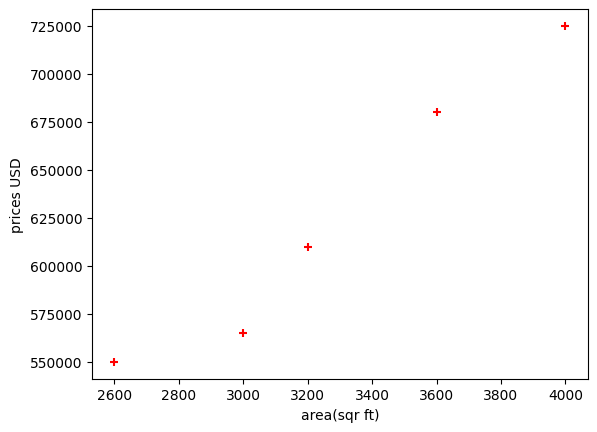

In [32]:
plt.scatter(df.area,df.price,color='Red',marker='+')
plt.xlabel("area(sqr ft)")
plt.ylabel("prices USD")

In [33]:
lr = lm.LinearRegression()
lr.fit(df[['area']],df.price)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
lr.predict([[3300]])

/Users/bpruthivi/Projects/ML/ML-Notes/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([628715.75342466])

In [35]:
lr.intercept_

np.float64(180616.43835616432)

In [36]:
d = pd.read_csv("areas.csv")
d

,area,Model_predicted_prices
0,1000,3.164041e+05
1,1500,3.842979e+05
2,2300,4.929281e+05
3,3540,6.613048e+05
4,4120,7.400616e+05
5,4560,7.998082e+05
6,5490,9.260908e+05
7,3460,6.504418e+05
8,4750,8.256079e+05
9,2300,4.929281e+05


In [37]:
p=lr.predict([[x] for x in d['area']])
d['Model_predicted_prices']=p
d.to_csv("areas.csv",index=False)

/Users/bpruthivi/Projects/ML/ML-Notes/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


/Users/bpruthivi/Projects/ML/ML-Notes/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


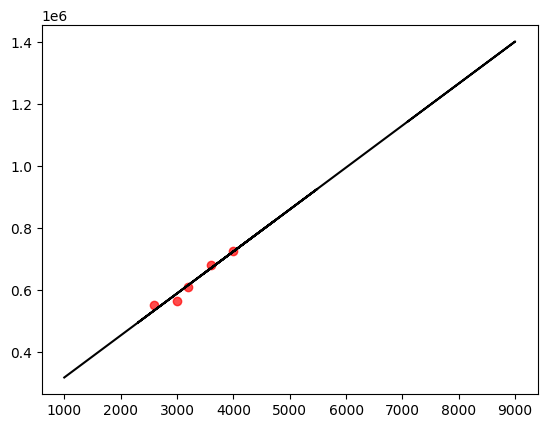

In [38]:
plt.plot(d.area,lr.predict([[x] for x in d['area']]), color='black')
plt.scatter(df.area,df.price,color='red',alpha=0.7)

In [39]:
nd=pd.read_csv("canada_per_capita_income.csv")
nd.head(4)
nd.rename(columns={"per capita income (US$)":"income"},inplace=True)

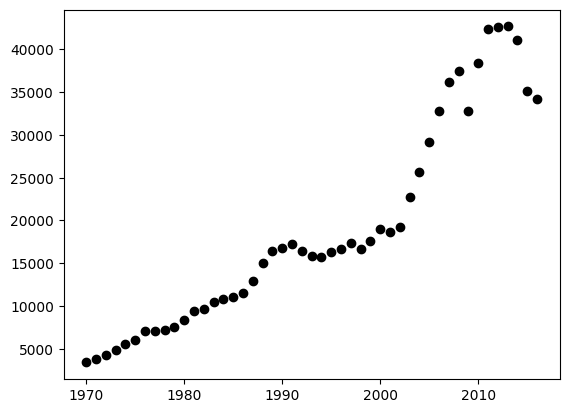

In [40]:
plt.scatter(nd.year,nd.income,color="black")
ex = lr.fit(nd[['year']],nd.income)
new = ex.predict(nd[['year']])

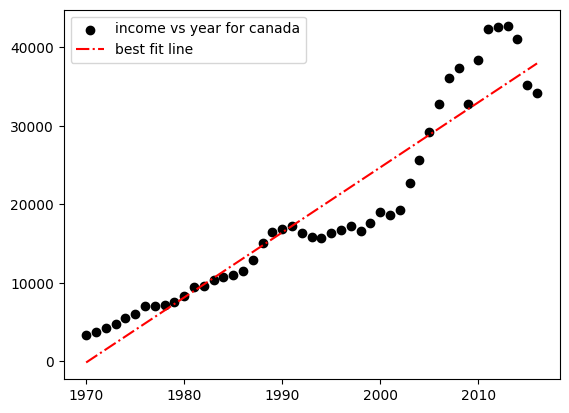

In [41]:
plt.scatter(nd.year,nd.income,color="black",label="income vs year for canada")
plt.plot(nd.year,new,color='red',linestyle='-.',label="best fit line")
plt.legend()